In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [2]:
# Load the cleaned Superstore dataset
df = pd.read_csv("../data/cleaned_superstore.csv")

# Display the first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
1,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
4,7,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


In [3]:
# Descriptive Statistics for numerical columns

print("Mean:\n")
print(df[['Sales', 'Profit', 'Quantity', 'Discount']].mean())

print("\nMedian:\n")
print(df[['Sales', 'Profit', 'Quantity', 'Discount']].median())

print("\nMode:\n")
print(df[['Sales', 'Profit', 'Quantity', 'Discount']].mode().iloc[0])

print("\nStandard Deviation:\n")
print(df[['Sales', 'Profit', 'Quantity', 'Discount']].std())

print("\nSkewness:\n")
print(df[['Sales', 'Profit', 'Quantity', 'Discount']].skew())

Mean:

Sales       92.864853
Profit      11.198644
Quantity     3.608587
Discount     0.157606
dtype: float64

Median:

Sales       40.8800
Profit       7.4376
Quantity     3.0000
Discount     0.2000
dtype: float64

Mode:

Sales       12.96
Profit       0.00
Quantity     2.00
Discount     0.00
Name: 0, dtype: float64

Standard Deviation:

Sales       114.045078
Profit       49.066101
Quantity      2.129308
Discount      0.211531
dtype: float64

Skewness:

Sales       1.685035
Profit     -4.713308
Quantity    1.350316
Discount    1.687821
dtype: float64


In [4]:
# Compare Sales between Consumer and Corporate segments

consumer_sales = df[df['Segment'] == 'Consumer']['Sales']
corporate_sales = df[df['Segment'] == 'Corporate']['Sales']


In [5]:
# Perform Independent t-test

t_stat, p_value = stats.ttest_ind(consumer_sales, corporate_sales)

print("T-Statistic:", t_stat)
print("P-Value:", p_value)

T-Statistic: 1.2937166732357739
P-Value: 0.19580445498210286


### Interpretation of t-test

- Null Hypothesis (H₀): There is no significant difference in Sales between Consumer and Corporate segments.
- Alternative Hypothesis (H₁): There is a significant difference in Sales between Consumer and Corporate segments.

If the **p-value < 0.05**, we reject the null hypothesis and conclude that the sales differ significantly.

If the **p-value ≥ 0.05**, we fail to reject the null hypothesis, indicating no statistically significant difference.

In [6]:
# Contingency table for Category and Segment

contingency_table = pd.crosstab(df["Category"], df["Segment"])

print(contingency_table)

Segment          Consumer  Corporate  Home Office
Category                                         
Furniture             881        491          282
Office Supplies      2989       1710         1027
Technology            756        436          255


In [8]:
# Chi-Square Test

chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p_value)
print("Degrees of Freedom:", dof)

Chi-Square Statistic: 0.9156041793577616
P-Value: 0.9223115495495535
Degrees of Freedom: 4


### Interpretation of Chi-Square Test

- **Null Hypothesis (H₀):** Category and Segment are independent.
- **Alternative Hypothesis (H₁):** Category and Segment are associated.

If the **p-value < 0.05**, we reject the null hypothesis and conclude that there is a significant association.

If the **p-value ≥ 0.05**, we fail to reject the null hypothesis, indicating no significant association.

In [9]:
# 95% Confidence Interval for Sales

confidence = 0.95

mean_sales = df["Sales"].mean()
std_sales = df["Sales"].std()
n = len(df["Sales"])

margin_of_error = stats.t.ppf((1 + confidence) / 2, n - 1) * (std_sales / np.sqrt(n))

lower_bound = mean_sales - margin_of_error
upper_bound = mean_sales + margin_of_error

print("Mean Sales:", mean_sales)
print("95% Confidence Interval:")
print(f"({lower_bound:.2f}, {upper_bound:.2f})")

Mean Sales: 92.86485276991051
95% Confidence Interval:
(90.49, 95.24)


### Interpretation of 95% Confidence Interval

The 95% confidence interval provides a range within which the true average sales value is expected to lie with 95% confidence. It helps estimate the population mean based on the sample data.

# Statistical Findings

## Descriptive Statistics
The descriptive statistics summarize the central tendency and variability of the numerical variables. Sales and Profit show a wide range of values, while Quantity and Discount have comparatively lower variation.

## Hypothesis Testing (t-test)
An independent t-test was performed to compare the sales of Consumer and Corporate customer segments. The test determines whether there is a statistically significant difference between the average sales of the two groups.

## Chi-Square Test
The Chi-Square test was used to examine the relationship between Product Category and Customer Segment. The result indicates whether these two categorical variables are statistically associated.

## Confidence Interval
A 95% confidence interval was calculated for the Sales variable to estimate the range in which the true population mean is likely to fall. This provides a reliable estimate of the average sales value.

In [10]:
# Convert Order Date to datetime
df["Order Date"] = pd.to_datetime(df["Order Date"])

# Set Order Date as the index
df = df.set_index("Order Date")

# Verify the time series format
df.head()

,Row ID,Order ID,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
Order Date,,,,,,,,,,,,,,,,,,,,
2016-11-08,1,CA-2016-152156,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.960,2,0.0,41.9136
2016-06-12,3,CA-2016-138688,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.620,2,0.0,6.8714
2015-10-11,5,US-2015-108966,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.368,2,0.2,2.5164
2014-06-09,6,CA-2014-115812,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.860,7,0.0,14.1694
2014-06-09,7,CA-2014-115812,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,90032,West,OFF-AR-10002833,Office Supplies,Art,Newell 322,7.280,4,0.0,1.9656


In [12]:
# Daily Sales Resampling

daily_sales = df["Sales"].resample("D").sum()

print(daily_sales.head())

Order Date
2014-01-03     16.448
2014-01-04    288.060
2014-01-05     19.536
2014-01-06    467.340
2014-01-07     87.158
Freq: D, Name: Sales, dtype: float64


In [13]:
# Weekly Sales Resampling

weekly_sales = df["Sales"].resample("W").sum()

print(weekly_sales.head())

Order Date
2014-01-05     324.044
2014-01-12     659.812
2014-01-19    1418.017
2014-01-26    2074.518
2014-02-02    1642.310
Freq: W-SUN, Name: Sales, dtype: float64


In [14]:
# Monthly Sales Resampling

monthly_sales = df["Sales"].resample("ME").sum()

print(monthly_sales.head())

Order Date
2014-01-31     5438.155
2014-02-28     3263.672
2014-03-31    12452.536
2014-04-30    11421.191
2014-05-31    10456.715
Freq: ME, Name: Sales, dtype: float64


In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose

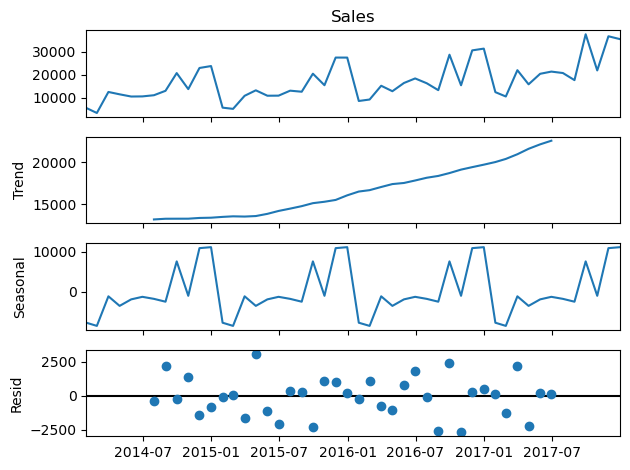

In [16]:
# Decompose monthly sales into trend, seasonality and residuals

decomposition = seasonal_decompose(
    monthly_sales,
    model="additive",
    period=12
)

decomposition.plot()

plt.show()

In [17]:
# Calculate 3-month Moving Average

monthly_sales_ma = monthly_sales.rolling(window=3).mean()

print(monthly_sales_ma.head())

Order Date
2014-01-31             NaN
2014-02-28             NaN
2014-03-31     7051.454333
2014-04-30     9045.799667
2014-05-31    11443.480667
Freq: ME, Name: Sales, dtype: float64


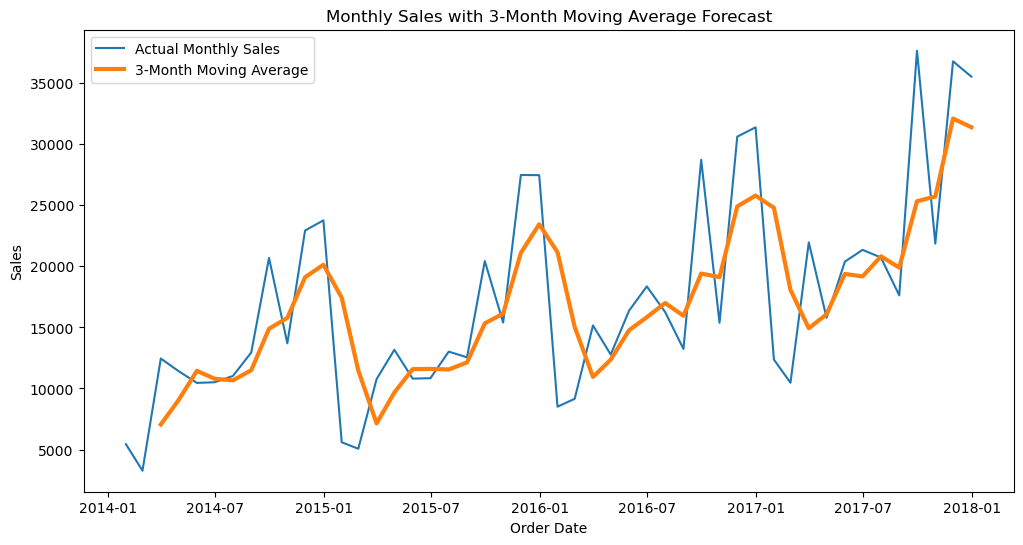

In [19]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales, label="Actual Monthly Sales")
plt.plot(monthly_sales_ma, label="3-Month Moving Average", linewidth=3)

plt.title("Monthly Sales with 3-Month Moving Average Forecast")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()

plt.savefig("../dashboards/moving_average_forecast.png", dpi=300)

plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler

In [21]:
# Select numerical features for clustering

features = df[["Sales", "Profit", "Quantity"]]

features.head()

,Sales,Profit,Quantity
Order Date,,,
2016-11-08,261.960,41.9136,2
2016-06-12,14.620,6.8714,2
2015-10-11,22.368,2.5164,2
2014-06-09,48.860,14.1694,7
2014-06-09,7.280,1.9656,4


In [22]:
# Scale the features

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

print(scaled_features[:5])

[[ 1.48278847  0.62602685 -0.75549349]
 [-0.68612593 -0.08819712 -0.75549349]
 [-0.61818404 -0.17695996 -0.75549349]
 [-0.38587677  0.06054944  1.59282014]
 [-0.75049009 -0.18818627  0.18383196]]


In [23]:
from sklearn.cluster import KMeans

In [30]:
# Apply K-Means Clustering using the optimal K = 4

kmeans = KMeans(n_clusters=4, random_state=42)

clusters = kmeans.fit_predict(scaled_features)

clusters[:10]

array([1, 0, 0, 3, 0, 0, 3, 0, 1, 2])

In [31]:
# Add cluster labels to the dataset

df["Cluster"] = clusters

df[["Sales", "Profit", "Quantity", "Cluster"]].head()

,Sales,Profit,Quantity,Cluster
Order Date,,,,
2016-11-08,261.960,41.9136,2,1
2016-06-12,14.620,6.8714,2,0
2015-10-11,22.368,2.5164,2,0
2014-06-09,48.860,14.1694,7,3
2014-06-09,7.280,1.9656,4,0


In [32]:
# Calculate WCSS for K = 1 to 10

wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    wcss.append(model.inertia_)

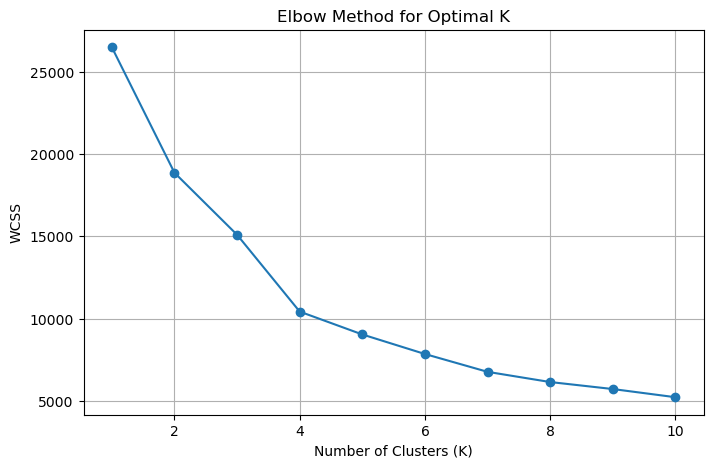

In [33]:
# Plot the Elbow Method

plt.figure(figsize=(8,5))

plt.plot(range(1, 11), wcss, marker="o")

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [34]:
from sklearn.decomposition import PCA

In [35]:
# Reduce data to 2 dimensions using PCA

pca = PCA(n_components=2)

pca_features = pca.fit_transform(scaled_features)

print(pca_features[:5])

[[ 0.91683032 -1.11912018]
 [-0.87820574 -0.47757116]
 [-0.8854049  -0.43045332]
 [ 0.6077933   1.25978782]
 [-0.49282848  0.33165522]]


In [37]:
# Create DataFrame for PCA visualization

pca_df = pd.DataFrame(
    pca_features,
    columns=["PCA1", "PCA2"]
)

# Add cluster labels directly
pca_df["Cluster"] = clusters

pca_df.head()

,PCA1,PCA2,Cluster
0,0.916830,-1.119120,1
1,-0.878206,-0.477571,0
2,-0.885405,-0.430453,0
3,0.607793,1.259788,3
4,-0.492828,0.331655,0


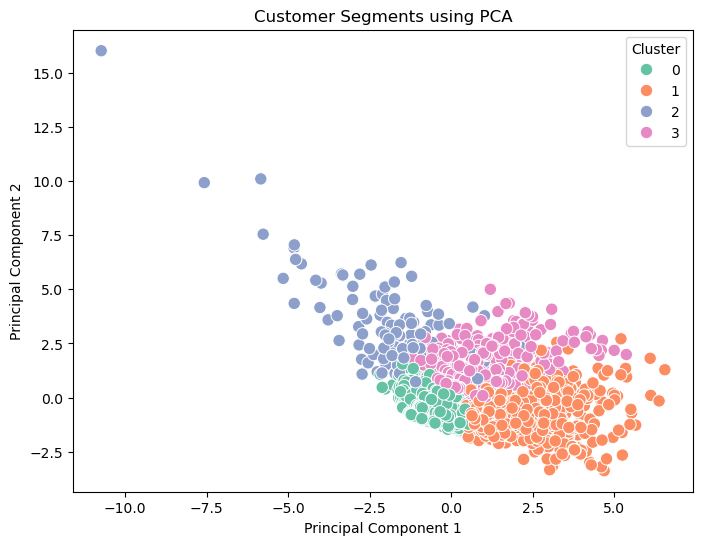

In [38]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Cluster")
plt.show()

In [39]:
# Profile each cluster

cluster_profile = df.groupby("Cluster")[["Sales", "Profit", "Quantity"]].mean()

cluster_profile

,Sales,Profit,Quantity
Cluster,,,
0,43.747237,5.953330,2.466779
1,301.047833,60.199110,3.964286
2,299.347220,-181.394316,3.995192
3,61.788134,12.402137,6.508607


# Customer Segment Recommendations

### Cluster 0
- Customers in this segment have moderate purchasing behavior.
- Recommendation: Offer loyalty rewards and personalized discounts to increase repeat purchases.

### Cluster 1
- Customers generate high sales and profits.
- Recommendation: Retain these high-value customers through premium services, exclusive offers, and membership programs.

### Cluster 2
- Customers have lower sales and profit contribution.
- Recommendation: Use targeted promotions, bundled products, and marketing campaigns to improve engagement.

### Cluster 3
- Customers purchase in higher quantities but may generate lower profit margins.
- Recommendation: Optimize pricing, reduce discount dependency, and promote higher-margin products to improve profitability.

In [40]:
# Features (Independent Variables)
X = df[["Profit", "Quantity", "Discount"]]

# Target Variable (Dependent Variable)
y = df["Sales"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
             Profit  Quantity  Discount
Order Date                             
2016-11-08  41.9136         2       0.0
2016-06-12   6.8714         2       0.0
2015-10-11   2.5164         2       0.2
2014-06-09  14.1694         7       0.0
2014-06-09   1.9656         4       0.0

Target:
Order Date
2016-11-08    261.960
2016-06-12     14.620
2015-10-11     22.368
2014-06-09     48.860
2014-06-09      7.280
Name: Sales, dtype: float64


In [41]:
from sklearn.model_selection import train_test_split

In [42]:
# Split data into training (80%) and testing (20%)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [43]:
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)
print("Testing Target  :", y_test.shape)

Training Features: (7061, 3)
Testing Features : (1766, 3)
Training Target : (7061,)
Testing Target  : (1766,)


In [44]:
from sklearn.linear_model import LinearRegression

In [45]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [46]:
# Predict Sales on the test data

y_pred = model.predict(X_test)

print("First 10 Predictions:")
print(y_pred[:10])

First 10 Predictions:
[ 76.74714015  69.84613172  85.42932605  86.53674321 121.44695331
 108.95433872 108.85370986  68.5304859   84.29780978  74.052444  ]


In [47]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

In [48]:
# Evaluate the Linear Regression model

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score :", round(r2, 4))
print("MAE      :", round(mae, 2))
print("RMSE     :", round(rmse, 2))

R² Score : 0.0835
MAE      : 83.77
RMSE     : 110.22


In [49]:
# Get feature importance from Linear Regression coefficients

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# Sort by absolute coefficient values
feature_importance["Absolute Coefficient"] = feature_importance["Coefficient"].abs()

feature_importance = feature_importance.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

feature_importance

,Feature,Coefficient,Absolute Coefficient
1,Quantity,7.745109,7.745109
0,Profit,0.363679,0.363679
2,Discount,0.192938,0.192938


In [50]:
# Top 3 important features

top3 = feature_importance.head(3)

print(top3)

    Feature  Coefficient  Absolute Coefficient
1  Quantity     7.745109              7.745109
0    Profit     0.363679              0.363679
2  Discount     0.192938              0.192938


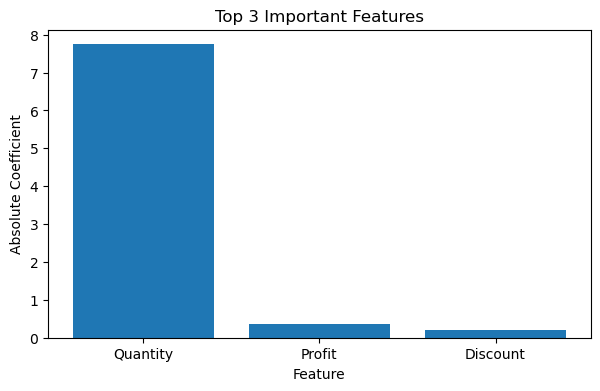

In [51]:
plt.figure(figsize=(7,4))

plt.bar(
    top3["Feature"],
    top3["Absolute Coefficient"]
)

plt.title("Top 3 Important Features")
plt.xlabel("Feature")
plt.ylabel("Absolute Coefficient")

plt.show()

## Business Interpretation

The feature importance analysis shows which variables have the strongest influence on predicting Sales.

- Features with larger absolute coefficients contribute more to the prediction.
- These insights help businesses focus on the most influential factors affecting sales performance.
- Managers can use this information to improve decision-making and optimize business strategies.